# Participant-Level TRF Analysis
## Per-participant boosting with whole and segmented trials
### Chan Myae | Supervisor: Dr Adele Simon | UCL | 2025

This notebook runs the TRF (Temporal Response Function) boosting analysis **per participant per condition**, extending the condition-level analysis in `eelbrain.ipynb`.

**Structure:**
1. Load MATLAB data into Eelbrain Datasets
2. Run boosting per participant (whole trials)
3. Segment trials (60s → 4 × 15s) and rerun boosting
4. Build chance model (shifted envelope) and run boosting
5. Statistical analyses (one-sample t-test, paired t-test)

**To adapt for a new dataset:** Update the file paths at the top of each section and adjust `SFREQ`, `N_TIMES`, and electrode coordinates accordingly.

In [ ]:
# importing important libraries
from eelbrain import * 
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import pickle
import scipy.stats as sp
from pathlib import Path
from scipy.io import loadmat

## Loading MATLAB data into Python (Eelbrain package)

In [ ]:
# File paths 
DATA_ROOT = Path(r"C:\Users\acer\Eelbrain\Processed")           # folder containing .mat condition files
figures_path = Path(r"C:\Users\acer\Eelbrain\participants_figures")  # output folder for whole trial figures
figures_path_seg = Path(r"C:\Users\acer\Eelbrain\participants_figures_segmented")  # output folder for segmented figures
pickle_path = Path(r"C:\Users\acer\Eelbrain")                      # folder to save pickle files

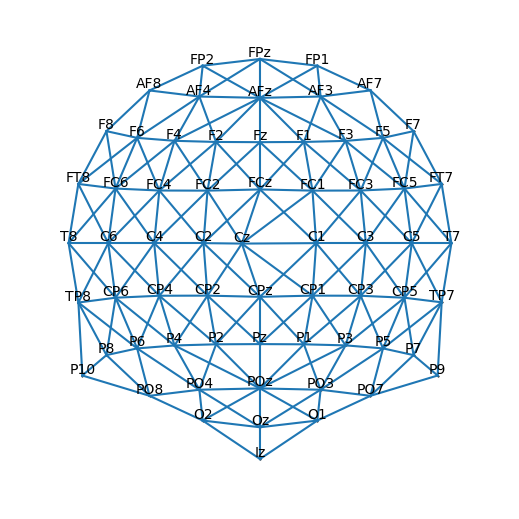

In [3]:
# creating the Sensor dimension from the electrode positions
ced = pd.read_csv(r"C:\Users\acer\Eelbrain\electrodes_locations.ced", 
                  sep='\t' # the .ced file is separated by tabs (\t)
                 )

names = ced['labels'].tolist() # extracts the electrode names and convert it to a Python list
locs = ced[['Y', 'X', 'Z']].values.astype(float) # extracts the x,y,z coordinates of the electrodes
sensor = Sensor(locs, names=names)
# defining adjacency 
sensor.set_adjacency(connect_dist=1.7)

# plotting the sensor positions 
p = plot.SensorMap(sensor, adjacency=True)

In [4]:
# creating constants to make the time dimension 
SFREQ = 128 # Hz
TSTEP = 1/SFREQ # time step 

# creating the Time dimension 
N_TIMES = 7680 # from EEG 
time = UTS(0, TSTEP, N_TIMES)

## Loading Files from MatLab

In [5]:
# making a dictionary for all conditions
conditions = {'mc': 'Data_Music_Cello.mat',
              'md': 'Data_Music_Danish.mat',
              'mf': 'Data_Music_Finnish.mat',
              'sd': 'Data_Speech_Danish.mat',
              'sf': 'Data_Speech_Finnish.mat',
}

# making a dictionary to store all 5 datasets 
ds_all = {}

# looping through each condition
for con, filename in conditions.items():
    mat = loadmat(DATA_ROOT / filename)
    data = mat[filename.replace('.mat', '')]

    rows = [] 
    for i in range(data.shape[1]): # looping through all the trials in each dataset 
        trial = data[0,i] # extracting details for each trial/row (data is a 2D array with shape (1,87))

        eeg_arr = trial['EEG_processed'] # eeg component (64, 7680)
        env_arr = trial['Audio_Envelope'][:,0] # the original envelope column is 2D (7680x1) ->  extracts all the content from the first column and convert it to 1D (7680,)

        eeg_ndvar = NDVar(eeg_arr, (sensor, time), name='eeg')
        env_ndvar = NDVar(env_arr, (time), name='envelope')
        rows.append({
                'participant': int(trial['Participant'].flat[0]), # since MATLAB stores these columns as nested array -> need to flatten them out 
                'trial': int(trial['Trial'].flat[0]),
                'audio_name': str(trial['Audio_Name'].flat[0]),
                'engagement': float(trial['Engagement'].flat[0]),
                'familiarity': float(trial['Familiarity'].flat[0]),
                'duration': N_TIMES/SFREQ,
                'eeg': eeg_ndvar,
                'envelope': env_ndvar,
            })

    # converting to Eelbrain dataset
    ds = Dataset({
        'participant': Var([r['participant'] for r in rows]),
        'trial':       Var([r['trial']       for r in rows]),
        'audio_name':  Factor([r['audio_name']  for r in rows]),
        'engagement':  Var([r['engagement']  for r in rows]),
        'familiarity': Var([r['familiarity'] for r in rows]),
        'duration':    Var([r['duration']    for r in rows]),
        'envelope':    combine([r['envelope']   for r in rows]), # combines the NDVars components of envelope
        'eeg':         combine([r['eeg']        for r in rows]),
    })

    ds_all[con] = ds

# extracting each condition into its own variable 
ds_mc = ds_all['mc']
ds_md = ds_all['md']
ds_mf = ds_all['mf']
ds_sd = ds_all['sd']
ds_sf = ds_all['sf']

# Participant Analysis

In [9]:
ds_mc.head()

#,participant,trial,audio_name,engagement,familiarity,duration
0,1,12,5_MC.,73.128,27.495,60
1,1,15,4_MC.,71.789,20.594,60
2,1,16,1_MC.,74.364,9.9837,60
3,1,18,3_MC.,84.459,90.124,60
4,1,23,2_MC.,77.969,79.617,60
5,2,14,3_MC.,90.124,90,60
6,2,16,4_MC.,90,10,60
7,2,17,5_MC.,90,90,60
8,2,23,1_MC.,90,44.182,60
9,2,28,2_MC.,90,10,60


In [ ]:
# exploratory check: how many trials does participant 1 have in Music Cello?
unique_mc_1 = ds_mc.sub("participant == 1") 
print(unique_mc_1.n_cases)

In [ ]:
# ── Per-participant TRF estimation (whole trials) ──────────────────────────
# Runs boosting separately for each participant within each condition.
# Results stored in nested dictionaries: trf_results[condition][participant]

all_participants = {}  # stores each participant's Dataset per condition
trf_results = {}       # stores TRF results (shape, predictive power, r) per participant per condition

for con, ds in ds_all.items(): # for each condition and its dataset
    all_participants[con] = {}
    trf_results[con] = {}
    unique_participants = np.unique(ds['participant']) # unique participant numbers (not all 22 — some excluded due to noise artefacts)
    for p in unique_participants:
        all_participants[con][p] = ds.sub(f"participant == {p}") # extract this participant's trials
        trial_num = all_participants[con][p].n_cases
        # partitions = trial_num (leave-one-out approach per participant)
        # a fixed k (e.g. k=4) is NOT used because some participants only have 3 trials,
        # and k must divide evenly into the number of trials to avoid uneven splits
        trf = boosting('eeg', 'envelope', -0.100, 0.750,
                        data=all_participants[con][p],
                        basis=0.050, partitions=trial_num, test=True)
        trf_results[con][p] = {
            'trf_shape': trf.h,                             # estimated TRF (time x sensors)
            'GFP_max_time': trf.h.std('sensor').argmax('time'), # time of max global field power
            'predictive_power': trf.proportion_explained,   # R² per sensor
            'correlation_coefficient': trf.r,               # correlation between predicted and actual EEG
        }
        print(f"Done: {con} - Participant {p} ({trial_num} trials)")

In [9]:
with open(pickle_path / "trf_results_whole.pkl", "wb") as f:
    pickle.dump(trf_results, f) 

print("Whole trial TRF results saved.")

Whole trial TRF results saved.


In [ ]:
# ── Save TRF plots for each participant (whole trials) ────────────────────
# Saves 4 figures per participant per condition:
#   1. TRF butterfly plot (all sensors over time) at GFP maximum
#   2. TopoArray at 60ms and 200ms (key time points from paper Figure 5)
#   3. Predictive power topomap (R²)
#   4. Mean r topomap (correlation coefficient)

for con, ds in ds_all.items():
    unique_participants = np.unique(ds['participant'])
    for p in unique_participants:
        # trf plot
        fig = plot.TopoButterfly(trf_results[con][p]['trf_shape'], t=trf_results[con][p]['GFP_max_time'], w=10, h=4, clip='circle')
        fig.figure.savefig(figures_path / f'trf_shape_{con}_participant{p}.png', dpi=300, bbox_inches='tight')
        plt.close('all') # closes all open figures to prevent memory buildup
        
        # trf topoarray
        fig = plot.TopoArray(trf_results[con][p]['trf_shape'], t=[0.060, 0.200, None], w=6, h=4, clip='circle')
        fig.figure.savefig(figures_path / f'topoarray_{con}_participant{p}.png', dpi=300, bbox_inches='tight')
        plt.close('all')
        
        # predictive power
        title = f"Mean exp: {trf_results[con][p]['predictive_power'].mean('sensor'):.2%}"
        fig = plot.Topomap(trf_results[con][p]['predictive_power'], clip='circle', title=title)
        pcb = fig.plot_colorbar('Proportion explained')
        fig.figure.savefig(figures_path / f'pp_{con}_participant{p}.png', dpi=300, bbox_inches='tight')
        plt.close('all')

        # mean r
        title = f"Mean r: {trf_results[con][p]['correlation_coefficient'].mean('sensor'):.2}"
        fig = plot.Topomap(trf_results[con][p]['correlation_coefficient'], clip='circle', title=title)
        pcb = fig.plot_colorbar('Correlation (r)')
        fig.figure.savefig(figures_path / f'mean_r_{con}_participant{p}.png', dpi=300, bbox_inches='tight')
        plt.close('all')

In [10]:
# making a table of mean r values 
participants = np.unique(ds_mc['participant']) # using the unique participants of ds_mc since unique participants are the same in every condition
mean_r_ds = Dataset({
    'Participant': Var([p for p in participants]), 
    'Music_Cello': Var([trf_results['mc'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
    'Music_Danish': Var([trf_results['md'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
    'Music_Finnish': Var([trf_results['mf'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
    'Speech_Danish': Var([trf_results['sd'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
    'Speech_Finnish': Var([trf_results['sf'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
})

print(mean_r_ds)

#    Participant   Music_Cello   Music_Danish   Music_Finnish   Speech_Danish   Speech_Finnish
----------------------------------------------------------------------------------------------
0    1             0.015586      0.028826       0.021623        0.012791        0.0085145     
1    2             0.00087781    -0.0039037     -0.0068006      0.012383        0.01692       
2    3             0.018498      0.020223       0.00094265      0.019222        0.036537      
3    4             0.0064157     -0.0034987     0.011299        0.023239        0.0046282     
4    5             0.019501      0.018921       0.0028921       0.0019913       0.027171      
5    6             0.025442      0.022806       0.0019867       0.049156        0.04724       
6    7             0.00089068    -0.0067578     0.022443        0.027787        0.017746      
7    8             0.0097261     0.029612       0.041617        0.017087        0.033452      
8    9             0.014214      0.0052561      -0

In [12]:
# saving the data as CSV file 
mean_r_df = mean_r_ds.as_dataframe() 
mean_r_df.to_csv(r'C:\Users\acer\Eelbrain\participants_mean_r_values.csv', index=False) # remove index in the csv table 

In [22]:
# saving as MATLAB .mat file 
from scipy.io import savemat 
import numpy as np 

mean_r_mat = {
    'Participant': np.array([p for p in participants]), 
    'Music_Cello': np.array([trf_results['mc'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
    'Music_Danish': np.array([trf_results['md'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
    'Music_Finnish': np.array([trf_results['mf'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
    'Speech_Danish': np.array([trf_results['sd'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
    'Speech_Finnish': np.array([trf_results['sf'][p]['correlation_coefficient'].mean('sensor') for p in participants]),
}

savemat(r'C:\Users\chanm\eelbrain\participants_mean_r_values_matlab.mat', mean_r_mat)

# Trial Segmentation (60s → 4 × 15s)
## Increasing data segments for cross-validation

In [13]:
# creating new time dimensions for 15-second segments 
segment_length = 15 # seconds 
segment_samples = int(segment_length * SFREQ) # 15x128 = 1920 samples 
time_segment = UTS(0, TSTEP, segment_samples)

# build new segmented dataset for each condition 
ds_all_segmented = {} 

for con, ds in ds_all.items():
    rows = [] 
    for i in range(ds.n_cases): # looping through each trial 
        # extracting the raw EEG and envelope arrays (EEG = (64,7680), envelope=(7680,))
        eeg_trial = ds[i, 'eeg'].x # .x extracts the raw numpy array from inside the NDVar
        env_trial = ds[i, 'envelope'].x 

        for seg in range(4): # split into 4 segments 
            start = seg * segment_samples 
            end = start + segment_samples 

            rows.append({
                'participant': int(ds[i, 'participant']),
                'trial': int(ds[i, 'trial']),
                'segment': seg + 1, # since seg starts from 0 
                'audio_name': str(ds[i, 'audio_name']),
                'eeg': NDVar(eeg_trial[:, start:end], (sensor, time_segment), name='eeg'),
                'envelope': NDVar(env_trial[start:end], (time_segment), name='envelope'),
            }) # familiarity and engagement not added bc those values are for the whole trial 

    # build segmented Dataset
    ds_seg = Dataset() 
    ds_seg['participant'] = Var([r['participant'] for r in rows])
    ds_seg['trial'] = Var([r['trial'] for r in rows])
    ds_seg['segment'] = Var([r['segment'] for r in rows])
    ds_seg['audio_name'] = Factor([r['audio_name'] for r in rows])
    ds_seg['eeg'] = combine([r['eeg'] for r in rows])
    ds_seg['envelope'] = combine([r['envelope'] for r in rows])

    ds_all_segmented[con] = ds_seg    

# extracting each condition into its own variable 
ds_segmented_mc = ds_all_segmented['mc']
ds_segmented_md = ds_all_segmented['md']
ds_segmented_mf = ds_all_segmented['mf']
ds_segmented_sd = ds_all_segmented['sd']
ds_segmented_sf = ds_all_segmented['sf']

In [ ]:
# ── Per-participant TRF estimation (segmented trials) ─────────────────────
# Same as the whole trial analysis above but using 4x more data segments per participant.
# Results stored in trf_results_seg[condition][participant]

trf_results_seg = {}

for con, ds in ds_all_segmented.items():
    trf_results_seg[con] = {} # dictionary for each condition's results
    unique_participants = np.unique(ds['participant'])
    for p in unique_participants:
        print(f"Running boosting for {con} - Participant {p}...")
        ds_p = ds.sub(f"participant == {p}")
        trial_num = ds_p.n_cases # now 4x more segments than whole trials
        trf = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_p, basis=0.050, partitions=trial_num, test=True)
        trf_results_seg[con][p] = {
            'trf_shape': trf.h,
            'GFP_max_time': trf.h.std('sensor').argmax('time'),
            'predictive_power': trf.proportion_explained,
            'correlation_coefficient': trf.r,
        }

In [15]:
with open(pickle_path / "trf_results_segmented.pkl", "wb") as f:
    pickle.dump(trf_results_seg, f) 

print("Segmented TRF results saved.")

Segmented TRF results saved.


In [ ]:
# plots 
for con, ds in ds_all_segmented.items():
    unique_participants = np.unique(ds['participant'])
    for p in unique_participants:
        # trf plot 
        fig = plot.TopoButterfly(trf_results_seg[con][p]['trf_shape'], t=trf_results_seg[con][p]['GFP_max_time'], w=10, h=4, clip='circle')
        fig.figure.savefig(figures_path_seg / f'trf_shape_seg_{con}_participant{p}.png', dpi=300, bbox_inches='tight')
        plt.close('all')

        # topoarray 
        fig = plot.TopoArray(trf_results_seg[con][p]['trf_shape'], t=[0.060, 0.200, None], w=6, h=4, clip='circle')
        fig.figure.savefig(figures_path_seg / f'topoarray_seg_{con}_participant{p}.png', dpi=300, bbox_inches='tight')
        plt.close('all') 
        
        # predictive power 
        title = f"Mean exp: {trf_results_seg[con][p]['predictive_power'].mean('sensor'):.2}"
        fig = plot.Topomap(trf_results_seg[con][p]['predictive_power'], clip='circle', title=title)
        pcb = fig.plot_colorbar('Proportion explained')
        fig.figure.savefig(figures_path_seg / f'pp_seg_{con}_participant{p}.png', dpi=300, bbox_inches='tight')
        plt.close('all')

        # mean r 
        title = f"Mean r: {trf_results_seg[con][p]['correlation_coefficient'].mean('sensor'):.2}"
        fig = plot.Topomap(trf_results_seg[con][p]['correlation_coefficient'], clip='circle', title=title)
        pcb = fig.plot_colorbar('Correlation (r)')
        fig.figure.savefig(figures_path_seg / f'mean_r_seg_{con}_participant{p}.png', dpi=300, bbox_inches='tight')
        plt.close('all')

In [17]:
# making a table of mean r values 
participants_seg = np.unique(ds_segmented_mc['participant']) 
mean_r_ds_seg = Dataset({
    'Participant': Var([p for p in participants_seg]), 
    'Music_Cello': Var([trf_results_seg['mc'][p]['correlation_coefficient'].mean('sensor') for p in participants_seg]),
    'Music_Danish': Var([trf_results_seg['md'][p]['correlation_coefficient'].mean('sensor') for p in participants_seg]),
    'Music_Finnish': Var([trf_results_seg['mf'][p]['correlation_coefficient'].mean('sensor') for p in participants_seg]),
    'Speech_Danish': Var([trf_results_seg['sd'][p]['correlation_coefficient'].mean('sensor') for p in participants_seg]),
    'Speech_Finnish': Var([trf_results_seg['sf'][p]['correlation_coefficient'].mean('sensor') for p in participants_seg]),
})

print(mean_r_ds_seg)

#    Participant   Music_Cello   Music_Danish   Music_Finnish   Speech_Danish   Speech_Finnish
----------------------------------------------------------------------------------------------
0    1             0.026489      0.01908        0.030163        0.016129        0.01657       
1    2             0.0004163     0.0071181      -0.0034811      0.01822         0.020964      
2    3             0.01663       0.025737       0.019154        0.020086        0.041266      
3    4             0.0097141     0.008485       0.016131        0.026858        0.0084365     
4    5             0.021715      0.022945       0.016472        0.0048821       0.031415      
5    6             0.029839      0.032959       0.0088544       0.055216        0.051571      
6    7             0.001498      0.0016706      0.031679        0.027321        0.017697      
7    8             0.017935      0.032106       0.052428        0.026439        0.038018      
8    9             0.016696      0.008894       0.

In [18]:
# saving the data as CSV file 
mean_r_df = mean_r_ds_seg.as_dataframe() 
mean_r_df.to_csv(r'C:\Users\acer\Eelbrain\participants_mean_r_values_segmented.csv', index=False) # remove index in the csv table 

In [28]:
pickle_path = Path(r"C:\Users\acer\Eelbrain")

stats_data = {
    'mean_r_ds': mean_r_ds,           # whole trial mean r table
    'mean_r_ds_seg': mean_r_ds_seg,   # segmented mean r table
    'participants': participants,       # participant numbers
    'participants_seg': participants_seg,
    'con_names': con_names,            # condition names
}

with open(pickle_path / 'stats_data.pkl', 'wb') as f:
    pickle.dump(stats_data, f)
print("Stats data saved.")

Stats data saved.


# Statistical Analyses

## One Sample t-test

In [27]:
# one sample t-test against 0 for each condition 
con_names = list(mean_r_ds.keys())[1:] # skips 'participant' column

## whole trials 
print("=== Whole trials ===")
for con_name in con_names: # going through each condition
    ds_con = Dataset() # new empty dataset
    ds_con['mean_r'] = mean_r_ds[con_name] # fill with mean r values for this condition 
    results = test.TTestOneSample('mean_r', data=ds_con) # One Sample t-test for the condition
    print(f"\n{con_name}:")
    print(results)

## segmented trials 
print("\n")
print("=== Segmented trials ===")
for con_name in con_names: 
    ds_con = Dataset() 
    ds_con['mean_r'] = mean_r_ds_seg[con_name] 
    results = test.TTestOneSample('mean_r', data=ds_con)
    print(f"\n{con_name}:")
    print(results)

=== Whole trials ===

Music_Cello:
<TTestOneSample: mean_r = 0; difference = 0.01, t(17) = 4.47, p < .001>

Music_Danish:
<TTestOneSample: mean_r = 0; difference = 0.01, t(17) = 4.42, p < .001>

Music_Finnish:
<TTestOneSample: mean_r = 0; difference = 0.01, t(17) = 3.72, p = .002>

Speech_Danish:
<TTestOneSample: mean_r = 0; difference = 0.02, t(17) = 4.56, p < .001>

Speech_Finnish:
<TTestOneSample: mean_r = 0; difference = 0.02, t(17) = 5.94, p < .001>


=== Segmented trials ===

Music_Cello:
<TTestOneSample: mean_r = 0; difference = 0.02, t(17) = 4.90, p < .001>

Music_Danish:
<TTestOneSample: mean_r = 0; difference = 0.02, t(17) = 6.97, p < .001>

Music_Finnish:
<TTestOneSample: mean_r = 0; difference = 0.02, t(17) = 5.81, p < .001>

Speech_Danish:
<TTestOneSample: mean_r = 0; difference = 0.03, t(17) = 5.47, p < .001>

Speech_Finnish:
<TTestOneSample: mean_r = 0; difference = 0.02, t(17) = 7.06, p < .001>


## Chance Model
#### Shifting envelope by 5 seconds

In [21]:
SHIFT = int(5 * SFREQ) # 5 * 128 Hz = 640 samples shifted 

# building chance datasets for all conditions 
ds_all_chance = {} 

for con, ds in ds_all.items():
    rows = [] 
    for i in range(ds.n_cases):
        eeg_trial = ds[i, 'eeg'].x # raw EEG (64, 7680)
        env_trial = ds[i, 'envelope'].x # raw envelope (7680,)

        # shift envelope by 5 seconds 
        env_shifted = np.roll(env_trial, SHIFT) # np.roll shifts the last 640 samples to the beginning 

        rows.append({
            'participant': int(ds[i, 'participant']),
            'trial': int(ds[i, 'trial']),
            'audio_name': str(ds[i, 'audio_name']),
            'eeg': NDVar(eeg_trial, (sensor, time), name='eeg'),
            'envelope': NDVar(env_shifted, (time), name='envelope')
        })

    # chance Dataset 
    chance_ds = Dataset()
    chance_ds['participant'] = Var([r['participant'] for r in rows])
    chance_ds['trial'] = Var([r['trial'] for r in rows])
    chance_ds['audio_name'] = Factor([r['audio_name'] for r in rows])
    chance_ds['eeg'] = combine([r['eeg'] for r in rows])
    chance_ds['envelope'] = combine([r['envelope'] for r in rows])

    ds_all_chance[con] = chance_ds
    print(f"Built chance dataset for {con}")

print("All chance datasets built.")
        

Built chance dataset for mc
Built chance dataset for md
Built chance dataset for mf
Built chance dataset for sd
Built chance dataset for sf
All chance datasets built.


In [ ]:
# extracting each chance condition into its own variable for convenience
ds_chance_mc = ds_all_chance['mc']
ds_chance_md = ds_all_chance['md']
ds_chance_mf = ds_all_chance['mf']
ds_chance_sd = ds_all_chance['sd']
ds_chance_sf = ds_all_chance['sf']

In [29]:
trf_results_chance = {} 

for con, ds in ds_all_chance.items():
    trf_results_chance[con] = {}
    unique_participants = np.unique(ds['participant'])
    for p in unique_participants:
        print(f"Running chance boosting for {con} - Participant {p}...")
        ds_p = ds.sub(f"participant == {p}")
        trial_num = ds_p.n_cases
        trf = boosting('eeg', 'envelope', -0.100, 0.750, data=ds_p, basis=0.050, partitions=trial_num, test=True)
        trf_results_chance[con][p] = {
            'trf_shape': trf.h,
            'predictive_power': trf.proportion_explained,
            'correlation_coefficient': trf.r,
        }

print("All chance models fitted.")

# making a table of mean r values 
participants_chance = np.unique(ds_chance_mc['participant']) 
mean_r_ds_chance = Dataset({
    'Participant': Var([p for p in participants_chance]), 
    'Music_Cello': Var([trf_results_chance['mc'][p]['correlation_coefficient'].mean('sensor') for p in participants_chance]),
    'Music_Danish': Var([trf_results_chance['md'][p]['correlation_coefficient'].mean('sensor') for p in participants_chance]),
    'Music_Finnish': Var([trf_results_chance['mf'][p]['correlation_coefficient'].mean('sensor') for p in participants_chance]),
    'Speech_Danish': Var([trf_results_chance['sd'][p]['correlation_coefficient'].mean('sensor') for p in participants_chance]),
    'Speech_Finnish': Var([trf_results_chance['sf'][p]['correlation_coefficient'].mean('sensor') for p in participants_chance]),
})

print(mean_r_ds_chance)

# saving the data as CSV file 
mean_r_df = mean_r_ds_chance.as_dataframe() 
mean_r_df.to_csv(r'C:\Users\acer\Eelbrain\participants_mean_r_values_chance.csv', index=False) # remove index in the csv table 

Running chance boosting for mc - Participant 1...
Running chance boosting for mc - Participant 2...
Running chance boosting for mc - Participant 3...
Running chance boosting for mc - Participant 4...
Running chance boosting for mc - Participant 5...
Running chance boosting for mc - Participant 6...
Running chance boosting for mc - Participant 7...
Running chance boosting for mc - Participant 8...
Running chance boosting for mc - Participant 9...
Running chance boosting for mc - Participant 10...
Running chance boosting for mc - Participant 11...
Running chance boosting for mc - Participant 12...
Running chance boosting for mc - Participant 13...
Running chance boosting for mc - Participant 15...
Running chance boosting for mc - Participant 16...
Running chance boosting for mc - Participant 17...
Running chance boosting for mc - Participant 19...
Running chance boosting for mc - Participant 22...
Running chance boosting for md - Participant 1...
Running chance boosting for md - Particip

In [30]:
with open(pickle_path / 'trf_results_chance.pkl', 'wb') as f:
    pickle.dump(trf_results_chance, f)
print("TRF results for chance model saved.")

with open(pickle_path / 'mean_r_ds_chance.pkl', 'wb') as f:
    pickle.dump(mean_r_ds_chance, f)
print("Mean r values for chance model saved.")

TRF results for chance model saved.
Mean r values for chance model saved.


In [35]:
# making a dataset for paired t-test (real vs chance) for statistical analysis in Jamovi
paired_df = pd.DataFrame({
    'Participant': participants,
    'MC_real': [trf_results['mc'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'MC_chance': [trf_results_chance['mc'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'MD_real': [trf_results['md'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'MD_chance': [trf_results_chance['md'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'MF_real': [trf_results['mf'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'MF_chance': [trf_results_chance['mf'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'SD_real': [trf_results['sd'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'SD_chance': [trf_results_chance['sd'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'SF_real': [trf_results['sf'][p]['correlation_coefficient'].mean('sensor') for p in participants],
    'SF_chance': [trf_results_chance['sf'][p]['correlation_coefficient'].mean('sensor') for p in participants],
})

paired_df.to_csv(r'C:\Users\acer\Eelbrain\paired_real_vs_chance.csv', index=False)

In [ ]:
# conditions dictionary mapping short keys to full condition names
# used throughout statistical analyses for looping and labelling
conditions = {
    'mc': 'Music_Cello',
    'md': 'Music_Danish',
    'mf': 'Music_Finnish',
    'sd': 'Speech_Danish',
    'sf': 'Speech_Finnish'
}
n_conditions = len(conditions)  # used for Bonferroni correction (dividing alpha by number of tests)
con_names = list(conditions.values())  # list of full condition names for looping

In [34]:
# Normality test -- checking if paramtric or non-parametric tests should be used
print("Normality test")
# paired t-test assumes the sampling distribution of the differences between scores must be normally distributed 
for con, con_name in conditions.items():
    real_r_values = np.array([trf_results[con][p]['correlation_coefficient'].mean('sensor') for p in participants])
    chance_r_values = np.array([trf_results_chance[con][p]['correlation_coefficient'].mean('sensor') for p in participants])

    difference = real_r_values - chance_r_values 
    W, p_norm = sp.shapiro(difference) # Shapiro-Wilk test to test if difference is deviates from normal distribution
    # returns the W-statistic and p-value of the hypothesis test 
    print(f"{con_name}: W={W:.3f}, p={p_norm:.3f}")

Normality test
Music_Cello: W=0.913, p=0.099
Music_Danish: W=0.986, p=0.991
Music_Finnish: W=0.970, p=0.801
Speech_Danish: W=0.990, p=0.999
Speech_Finnish: W=0.957, p=0.547


**Normality check result:** All conditions passed Shapiro-Wilk (p > 0.05 for all) → the differences between real and chance r values are normally distributed → parametric paired t-test is appropriate (rather than non-parametric Wilcoxon signed-rank test).

### Paired t-test

In [37]:
# paired t-test (real vs chance) 

for con, con_name in conditions.items():
    real_r_values = np.array([trf_results[con][p]['correlation_coefficient'].mean('sensor') for p in participants])
    chance_r_values = np.array([trf_results_chance[con][p]['correlation_coefficient'].mean('sensor') for p in participants])

    t_stat, p_value = sp.ttest_rel(real_r_values, chance_r_values, alternative='greater') # to test if the real r values are greater than chance 
    p_corrected = min(p_value * n_conditions, 1.0) # Bonferroni correction, the p value is capped at 1.0 (max value)
    significant = "Yes" if p_value<0.05 else "No"
    
    print(f"\n{con_name}:")
    print(f"   t = {t_stat:.3f}")
    print(f"   p (uncorrected) = {p_value:.4f}") 
    print(f"   p (Bonferroni corrected) = {p_corrected:.4f}")
    print(f"   Significant?: {significant}")


Music_Cello:
   t = 4.809
   p (uncorrected) = 0.0001
   p (Bonferroni corrected) = 0.0004
   Significant?: Yes

Music_Danish:
   t = 5.560
   p (uncorrected) = 0.0000
   p (Bonferroni corrected) = 0.0001
   Significant?: Yes

Music_Finnish:
   t = 6.484
   p (uncorrected) = 0.0000
   p (Bonferroni corrected) = 0.0000
   Significant?: Yes

Speech_Danish:
   t = 4.561
   p (uncorrected) = 0.0001
   p (Bonferroni corrected) = 0.0007
   Significant?: Yes

Speech_Finnish:
   t = 6.426
   p (uncorrected) = 0.0000
   p (Bonferroni corrected) = 0.0000
   Significant?: Yes


**Result:** All five conditions show significantly higher prediction accuracy for the real envelope compared to the chance model (p < .001, Bonferroni-corrected). This confirms that TRF prediction is not due to chance — the boosting algorithm is capturing genuine stimulus-EEG relationships driven by the acoustic envelope.

## Speech vs Music
To test H1 from the paper (speech is tracked better than music due to speech-specific acoustic processing), mean r values are averaged across the two speech conditions (Danish + Finnish speech) and three music conditions (Cello + Danish + Finnish music) per participant. A paired t-test is then used to compare the two group averages.

In [38]:
# calculating averages of the prediction accuracies of music and speech conditions
mean_r_df_seg = mean_r_ds_seg.as_dataframe()

# calculate means 
mean_r_df_seg['Speech_Mean'] = (mean_r_df_seg['Speech_Danish'] +
                                mean_r_df_seg['Speech_Finnish']) / 2 
mean_r_df_seg['Music_Mean'] = (mean_r_df_seg['Music_Cello'] +
                               mean_r_df_seg['Music_Danish'] + 
                               mean_r_df_seg['Music_Finnish']) / 3 

# saving updated CSV 
mean_r_df_seg.to_csv(r'C:\Users\acer\Eelbrain\mean_r_seg_conditions_avg.csv', index=False)